DATA LOADING

In [3]:
import gdown

file_id = "1D0HCYDfDpz14OOFAyqvnbPUdiIKWHMmD"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "weather.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1D0HCYDfDpz14OOFAyqvnbPUdiIKWHMmD
To: /content/weather.csv
100%|██████████| 1.79M/1.79M [00:00<00:00, 111MB/s]


'weather.csv'

PREPROCESSING

In [4]:
import pandas as pd

# Load
df = pd.read_csv("weather.csv")

# Clean columns
df.columns = df.columns.str.replace(" ", "_").str.replace(".", "_")

# Target
df['Rain'] = (df['Data_Precipitation'] > 0).astype(int)

# Features
features = [
    'Data_Temperature_Avg_Temp',
    'Data_Temperature_Max_Temp',
    'Data_Temperature_Min_Temp',
    'Data_Wind_Speed',
    'Data_Wind_Direction'
]

df = df.dropna()

X = df[features]
y = df['Rain']

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Base Models

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression(max_iter=1000)

dt = DecisionTreeClassifier(max_depth=5)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression(max_iter=1000)

dt = DecisionTreeClassifier(max_depth=5)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

Boosting Models

In [10]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

GradientBoostingClassifier()

In [16]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

Voting Classifier

In [17]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('dt', dt),
        ('rf', rf),
        ('xgb', xgb)
    ],
    voting='soft'
)

voting.fit(X_train, y_train)

VotingClassifier(estimators=[('lr', LogisticRegression(max_iter=1000)),
                             ('dt', DecisionTreeClassifier(max_depth=5)),
                             ('rf',
                              RandomForestClassifier(class_weight='balanced',
                                                     max_depth=10,
                                                     n_estimators=200,
                                                     random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, devi...
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.1, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=6,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=200, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                 voting='soft')

Stacking Classifier

In [19]:
from sklearn.ensemble import StackingClassifier

stack = StackingClassifier(
    estimators=[
        ('lr', lr),
        ('dt', dt),
        ('rf', rf),
        ('xgb', xgb)
    ],
    final_estimator=LogisticRegression()
)

stack.fit(X_train, y_train)

StackingClassifier(estimators=[('lr', LogisticRegression(max_iter=1000)),
                               ('dt', DecisionTreeClassifier(max_depth=5)),
                               ('rf',
                                RandomForestClassifier(class_weight='balanced',
                                                       max_depth=10,
                                                       n_estimators=200,
                                                       random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              de...
                                              importance_type=None,
                                              interaction_constraints=None,
                                              learning_rate=0.1, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None, max_depth=6,
                                              max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=200, n_jobs=None,
                                              num_parallel_tree=None, ...))],
                   final_estimator=LogisticRegression())

Evaluation Function

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
def evaluate(name, model):
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    print(f"\n{name}")
    print(f"Accuracy: {acc*100:.2f}%")
    print(f"Precision: {prec*100:.2f}%")
    print(f"Recall: {rec*100:.2f}%")
    print(f"F1 Score: {f1*100:.2f}%")

Evaluate All Models

In [23]:
evaluate("Logistic Regression", lr)
evaluate("Decision Tree", dt)
evaluate("Random Forest", rf)
evaluate("Gradient Boosting", gb)
evaluate("XGBoost", xgb)
evaluate("Voting Classifier", voting)
evaluate("Stacking Classifier", stack)


Logistic Regression
Accuracy: 75.63%
Precision: 75.71%
Recall: 98.87%
F1 Score: 85.75%

Decision Tree
Accuracy: 77.28%
Precision: 77.71%
Recall: 97.26%
F1 Score: 86.39%

Random Forest
Accuracy: 74.68%
Precision: 85.14%
Recall: 79.79%
F1 Score: 82.38%

Gradient Boosting
Accuracy: 79.37%
Precision: 79.99%
Recall: 96.26%
F1 Score: 87.37%

XGBoost
Accuracy: 79.31%
Precision: 81.68%
Recall: 92.95%
F1 Score: 86.95%

Voting Classifier
Accuracy: 78.92%
Precision: 79.81%
Recall: 95.81%
F1 Score: 87.08%

Stacking Classifier
Accuracy: 79.13%
Precision: 81.59%
Recall: 92.79%
F1 Score: 86.83%


In [32]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stack = StackingClassifier(
    estimators=[
        ('gb', gb),
        ('xgb', xgb),
        ('rf', rf)
    ],
    final_estimator=LogisticRegression(C=0.5),
    passthrough=True
)

stack.fit(X_train, y_train)

evaluate("Final Stacking", stack)


Final Stacking
Accuracy: 79.19%
Precision: 81.63%
Recall: 92.83%
F1 Score: 86.87%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [29]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,   # IMPORTANT FIX
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

evaluate("Fixed XGBoost", xgb)


Fixed XGBoost
Accuracy: 79.46%
Precision: 81.53%
Recall: 93.48%
F1 Score: 87.10%


In [34]:
from sklearn.metrics import f1_score

# Get probability predictions (important: NOT predict())
probs = xgb.predict_proba(X_test)[:, 1]

print("\nThreshold Tuning (XGBoost):")

for t in [0.45, 0.5, 0.55, 0.6]:
    preds = (probs > t).astype(int)
    f1 = f1_score(y_test, preds)
    print(f"Threshold: {t} → F1 Score: {f1}")


Threshold Tuning (XGBoost):
Threshold: 0.45 → F1 Score: 0.874377421140011
Threshold: 0.5 → F1 Score: 0.8709677419354839
Threshold: 0.55 → F1 Score: 0.8660305343511451
Threshold: 0.6 → F1 Score: 0.8575875486381322


In [35]:
best_preds = (probs > 0.45).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, best_preds))

              precision    recall  f1-score   support

           0       0.72      0.34      0.47       865
           1       0.81      0.95      0.87      2484

    accuracy                           0.80      3349
   macro avg       0.77      0.65      0.67      3349
weighted avg       0.79      0.80      0.77      3349



Feature Importance

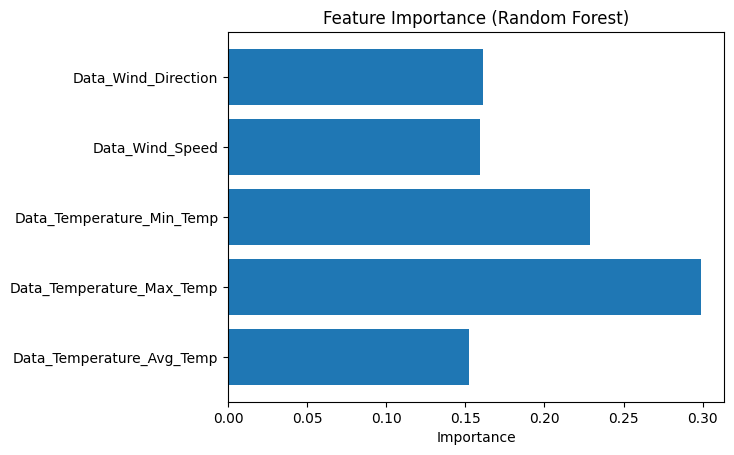

In [36]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_

plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.show()

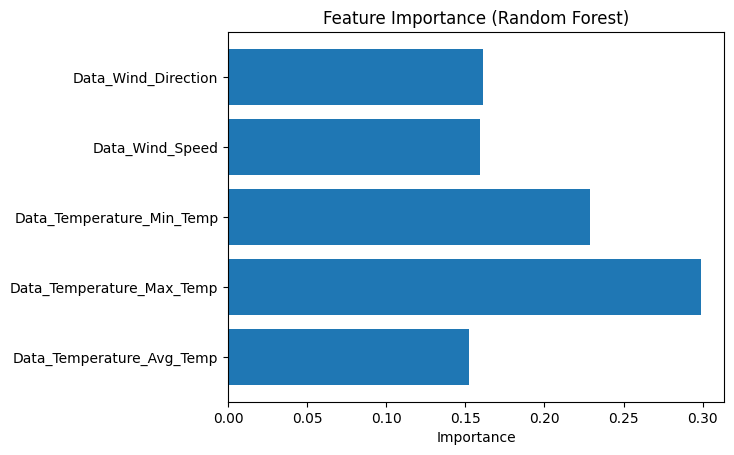

In [26]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_

plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.show()

SHAP Explainability

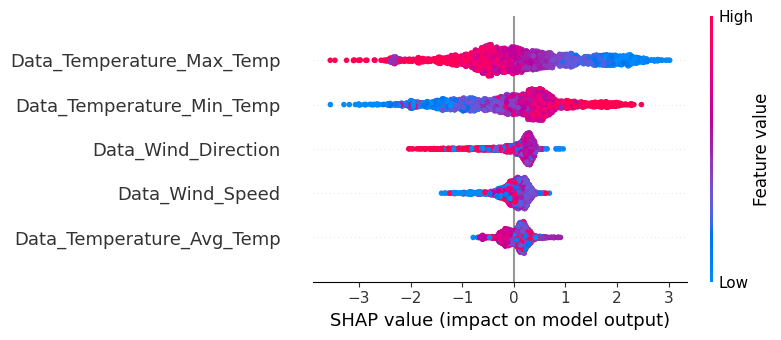

In [37]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [38]:
import joblib
joblib.dump(stack, "rain_model.pkl")

['rain_model.pkl']